# ESG Evaluation Metrics Analysis

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [ ]:
BASE = Path('.')
REPORTS_CSV = BASE / 'reports_metadata.csv'
PRE_CSV = BASE / 'preprocessing_runs.csv'
PRED_CSV = BASE / 'predictions.csv'
GT_CSV = BASE / 'ground_truth.csv'

reports_metadata.csv: OK
preprocessing_runs.csv: OK
predictions.csv: OK
ground_truth.csv: OK


In [5]:
reports = pd.read_csv(REPORTS_CSV) if REPORTS_CSV.exists() else pd.DataFrame()
pre = pd.read_csv(PRE_CSV) if PRE_CSV.exists() else pd.DataFrame()
pred = pd.read_csv(PRED_CSV) if PRED_CSV.exists() else pd.DataFrame()
gt = pd.read_csv(GT_CSV) if GT_CSV.exists() else pd.DataFrame()

print('reports', reports.shape)
print('pre', pre.shape)
print('pred', pred.shape)
print('gt', gt.shape)

reports (222, 11)
pre (59, 9)
pred (6098, 22)
gt (681, 8)


In [6]:
display(reports.head(3))
display(pre.head(3))
display(pred.head(3))
display(gt.head(3))

,report_id,company_name,industry,sub_industry,scope_key,total_pages,method,ablation,total_process_runtime_seconds,total_tokens,model
0,1d223dc1-ae3e-4c78-83e0-0a1329e528e0,bmw esg 2024,Transportation,Automobiles,Automobiles,19,M1,A0,164.894068,46794,gpt-5.2-2025-12-11
1,1d223dc1-ae3e-4c78-83e0-0a1329e528e0,20260331_062235_1d223dc1-ae3e-4c78-83e0-0a1329...,Transportation,Automobiles,Automobiles,19,M0,NaN,150.506500,194404,gpt-5.2-2025-12-11
2,897a33de-edbe-45aa-a425-31297df747c4,QAN_2024_Sustainability_Report,Transportation,Airlines,Airlines,92,M1,A0,1198.502065,60325,gpt-5.2-2025-12-11


,run_id,report_id,method,ablation,industry,sub_industry,scope_key,total_preprocess_runtime_seconds,timestamp
0,ddc832e5-87a0-4873-89b2-cc7b523c0436,1d223dc1-ae3e-4c78-83e0-0a1329e528e0,M1,A0,Transportation,Automobiles,Automobiles,28.742121,2026-03-31T17:23:06.250091+11:00
1,98dd9a7b-4573-4f06-bdbf-a25de000685f,1d223dc1-ae3e-4c78-83e0-0a1329e528e0,M0,NaN,Transportation,Automobiles,Automobiles,0.212423,2026-03-31T17:31:19.594351+11:00
2,71ff7d30-92fa-4121-9ec6-1ded816442c0,897a33de-edbe-45aa-a425-31297df747c4,M1,A0,Transportation,Airlines,Airlines,1081.545569,2026-03-31T18:01:14.427600+11:00


,pred_id,run_id,report_id,metric_id,industry,sub_industry,scope_key,model_name,method,ablation,...,pred_disclosure_status,pred_value,pred_unit,pred_page,pred_evidence_text,runtime_seconds,total_tokens,error_flag,error_message,timestamp
0,544190cf-c11a-4a3c-9f82-3a2d1b655f8c,ddc832e5-87a0-4873-89b2-cc7b523c0436,1d223dc1-ae3e-4c78-83e0-0a1329e528e0,sasb_0_Percentage_of_vehicle_models_rated_by_N...,Transportation,Automobiles,Automobiles,gpt-5.2-2025-12-11,M1,A0,...,not_disclosed,NaN,Percentage (%),NaN,NaN,8.340059,2183.0,0,NaN,2026-03-31T17:23:14.737216+11:00
1,f2e78aee-c4a7-4f24-8b70-e9ca0ee3869d,ddc832e5-87a0-4873-89b2-cc7b523c0436,1d223dc1-ae3e-4c78-83e0-0a1329e528e0,sasb_1_1_Number_of_safety-related_defect_compl...,Transportation,Automobiles,Automobiles,gpt-5.2-2025-12-11,M1,A0,...,not_disclosed,NaN,"Number, Percentage (%)",NaN,NaN,7.692159,2193.0,0,NaN,2026-03-31T17:23:22.452004+11:00
2,ca3fb8c4-bb4f-40a5-916d-816ce9dc31ea,ddc832e5-87a0-4873-89b2-cc7b523c0436,1d223dc1-ae3e-4c78-83e0-0a1329e528e0,sasb_2_2_percentage_investigated,Transportation,Automobiles,Automobiles,gpt-5.2-2025-12-11,M1,A0,...,not_disclosed,NaN,"Number, Percentage (%)",NaN,NaN,6.069265,2431.0,0,NaN,2026-03-31T17:23:28.554019+11:00


,gt_id,report_id,metric_id,industry,sub_industry,gt_disclosure_status,gt_value,gt_page
0,gt_000001,1d223dc1-ae3e-4c78-83e0-0a1329e528e0,sasb_0_Percentage_of_vehicle_models_rated_by_N...,Transportation,Automobiles,fully_disclosed,85(Euro) 100(China) 33(US) 100(Korea),12.0
1,gt_000002,1d223dc1-ae3e-4c78-83e0-0a1329e528e0,sasb_1_1_Number_of_safety-related_defect_compl...,Transportation,Automobiles,not_disclosed,NaN,NaN
2,gt_000003,1d223dc1-ae3e-4c78-83e0-0a1329e528e0,sasb_2_2_percentage_investigated,Transportation,Automobiles,not_disclosed,NaN,NaN


In [7]:
def to_num(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')

to_num(reports, ['total_pages', 'total_process_runtime_seconds', 'total_tokens'])
to_num(pre, ['total_preprocess_runtime_seconds'])
to_num(pred, ['runtime_seconds', 'total_tokens', 'pred_page'])
to_num(gt, ['gt_value'])

for df in [reports, pre, pred, gt]:
    for c in ['method', 'ablation', 'report_id', 'metric_id']:
        if c in df.columns:
            df[c] = df[c].astype(str).str.strip()

## Ground Truth Matching

In [8]:
eval_df = pd.DataFrame()
if {'report_id', 'metric_id', 'pred_disclosure_status'}.issubset(pred.columns) and {'report_id', 'metric_id', 'gt_disclosure_status'}.issubset(gt.columns):
    eval_df = pred.merge(gt, on=['report_id', 'metric_id'], how='inner')

print('matched rows:', len(eval_df))
display(eval_df.head(5))

matched rows: 5029


,pred_id,run_id,report_id,metric_id,industry_x,sub_industry_x,scope_key,model_name,method,ablation,...,total_tokens,error_flag,error_message,timestamp,gt_id,industry_y,sub_industry_y,gt_disclosure_status,gt_value,gt_page
0,544190cf-c11a-4a3c-9f82-3a2d1b655f8c,ddc832e5-87a0-4873-89b2-cc7b523c0436,1d223dc1-ae3e-4c78-83e0-0a1329e528e0,sasb_0_Percentage_of_vehicle_models_rated_by_N...,Transportation,Automobiles,Automobiles,gpt-5.2-2025-12-11,M1,A0,...,2183.0,0,NaN,2026-03-31T17:23:14.737216+11:00,gt_000001,Transportation,Automobiles,fully_disclosed,NaN,12.0
1,f2e78aee-c4a7-4f24-8b70-e9ca0ee3869d,ddc832e5-87a0-4873-89b2-cc7b523c0436,1d223dc1-ae3e-4c78-83e0-0a1329e528e0,sasb_1_1_Number_of_safety-related_defect_compl...,Transportation,Automobiles,Automobiles,gpt-5.2-2025-12-11,M1,A0,...,2193.0,0,NaN,2026-03-31T17:23:22.452004+11:00,gt_000002,Transportation,Automobiles,not_disclosed,NaN,NaN
2,ca3fb8c4-bb4f-40a5-916d-816ce9dc31ea,ddc832e5-87a0-4873-89b2-cc7b523c0436,1d223dc1-ae3e-4c78-83e0-0a1329e528e0,sasb_2_2_percentage_investigated,Transportation,Automobiles,Automobiles,gpt-5.2-2025-12-11,M1,A0,...,2431.0,0,NaN,2026-03-31T17:23:28.554019+11:00,gt_000003,Transportation,Automobiles,not_disclosed,NaN,NaN
3,163a481d-883d-415e-a1fc-a6953120e49d,ddc832e5-87a0-4873-89b2-cc7b523c0436,1d223dc1-ae3e-4c78-83e0-0a1329e528e0,sasb_3_Number_of_vehicles_recalled_1,Transportation,Automobiles,Automobiles,gpt-5.2-2025-12-11,M1,A0,...,2033.0,0,NaN,2026-03-31T17:23:35.824134+11:00,gt_000004,Transportation,Automobiles,not_disclosed,NaN,NaN
4,bfcc6527-25f8-41fb-b62f-a3ed44489a5d,ddc832e5-87a0-4873-89b2-cc7b523c0436,1d223dc1-ae3e-4c78-83e0-0a1329e528e0,sasb_4_Percentage_of_active_workforce_employed...,Transportation,Automobiles,Automobiles,gpt-5.2-2025-12-11,M1,A0,...,2481.0,0,NaN,2026-03-31T17:23:42.602303+11:00,gt_000005,Transportation,Automobiles,fully_disclosed,78.0,10.0


## Accuracy Metrics (`disclosure_status`)

,Model,N,Accuracy,Macro_F1
0,M0,695,0.8777,0.7185
1,M1_A0,1778,0.9021,0.7489



=== Markdown table ===
| Model   |    N |   Accuracy |   Macro_F1 |
|:--------|-----:|-----------:|-----------:|
| M0      |  695 |     0.8777 |     0.7185 |
| M1_A0   | 1778 |     0.9021 |     0.7489 |

=== LaTeX table ===
\begin{tabular}{lrrr}
\toprule
Model & N & Accuracy & Macro_F1 \\
\midrule
M0 & 695 & 0.877700 & 0.718500 \\
M1_A0 & 1778 & 0.902100 & 0.748900 \\
\bottomrule
\end{tabular}



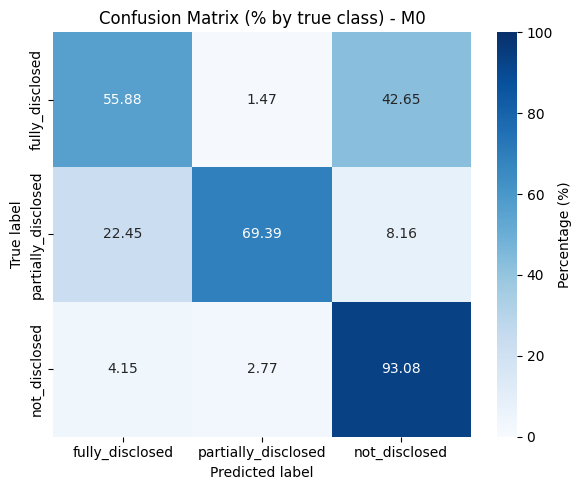

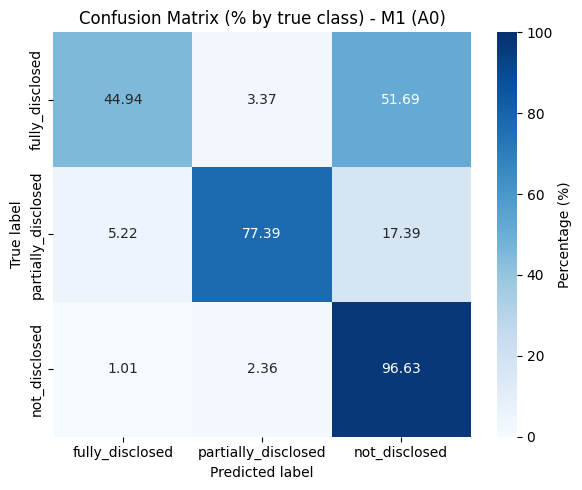


Export completed. Files saved in: F:\LingjingLan\0.ESG\EulerESG\EulerESG\uploads\outputs\experiment_logs\analysis_outputs


In [28]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# ---------- Config ----------
labels = ['fully_disclosed', 'partially_disclosed', 'not_disclosed']
OUT = Path('./analysis_outputs')
OUT.mkdir(parents=True, exist_ok=True)

# ---------- Prepare eval subset ----------
if eval_df.empty:
    raise ValueError("eval_df is empty. Please run the matching cell first.")

tmp = eval_df.copy()
tmp['gt_disclosure_status'] = tmp['gt_disclosure_status'].astype(str).str.strip().str.lower()
tmp['pred_disclosure_status'] = tmp['pred_disclosure_status'].astype(str).str.strip().str.lower()
tmp['method'] = tmp['method'].astype(str).str.strip()
if 'ablation' in tmp.columns:
    tmp['ablation'] = tmp['ablation'].astype(str).str.strip()

tmp = tmp[tmp['gt_disclosure_status'].isin(labels)].copy()
tmp.loc[~tmp['pred_disclosure_status'].isin(labels), 'pred_disclosure_status'] = 'not_disclosed'

slices = {
    'M0': tmp[tmp['method'].eq('M0')].copy(),
    'M1_A0': tmp[tmp['method'].eq('M1') & tmp['ablation'].fillna('').eq('A0')].copy(),
}

# ---------- Metrics table ----------
rows = []
for name, df_part in slices.items():
    if df_part.empty:
        rows.append({'Model': name, 'N': 0, 'Accuracy': np.nan, 'Macro_F1': np.nan})
        continue
    y_true = df_part['gt_disclosure_status']
    y_pred = df_part['pred_disclosure_status']
    rows.append({
        'Model': name,
        'N': len(df_part),
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'Macro_F1': round(f1_score(y_true, y_pred, labels=labels, average='macro', zero_division=0), 4),
    })

metrics_df = pd.DataFrame(rows)
display(metrics_df)

# ---------- Export tables ----------
metrics_df.to_csv(OUT / 'metrics_m0_m1a0.csv', index=False, encoding='utf-8-sig')

(OUT / 'metrics_m0_m1a0.md').write_text(
    metrics_df.to_markdown(index=False),
    encoding='utf-8'
)

(OUT / 'metrics_m0_m1a0.tex').write_text(
    metrics_df.to_latex(index=False, escape=False),
    encoding='utf-8'
)

# Also print for easy copy
print("\n=== Markdown table ===")
print(metrics_df.to_markdown(index=False))
print("\n=== LaTeX table ===")
print(metrics_df.to_latex(index=False, escape=False))

# ---------- Export confusion matrices ----------
def save_cm(df_part, title, out_png):
    if df_part.empty:
        print(f"Skip {title}: no data")
        return
    cm = confusion_matrix(df_part['gt_disclosure_status'], df_part['pred_disclosure_status'], labels=labels)
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)
    cm_pct = cm_df.div(cm_df.sum(axis=1).replace(0, np.nan), axis=0).fillna(0) * 100

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm_pct, annot=True, fmt='.2f',
        cmap='Blues', vmin=0, vmax=100,
        cbar_kws={'label': 'Percentage (%)'}
    )
    plt.title(title)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches='tight')
    plt.show()

save_cm(slices['M0'], 'Confusion Matrix (% by true class) - M0', OUT / 'cm_m0.png')
save_cm(slices['M1_A0'], 'Confusion Matrix (% by true class) - M1 (A0)', OUT / 'cm_m1_a0.png')

print(f"\nExport completed. Files saved in: {OUT.resolve()}")

## Value/Page Field Correctness (Binary)

In [29]:
import numpy as np
import pandas as pd

def norm_num_or_nan(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {'', 'n/a', 'na', 'none', 'null', '-', '--', '—'}:
        return np.nan
    s = s.replace(',', '')
    if s.endswith('%'):
        s = s[:-1].strip()
    try:
        v = float(s)
        return int(v) if abs(v - round(v)) < 1e-12 else v
    except Exception:
        return np.nan

def value_correct_including_na(gt_raw, pred_raw):
    g = norm_num_or_nan(gt_raw)
    p = norm_num_or_nan(pred_raw)
    if pd.isna(g) and pd.isna(p):
        return 1
    if pd.isna(g) ^ pd.isna(p):
        return 0
    return int(g == p)

def page_strict_correct_including_na(gt_raw, pred_raw):
    g = pd.to_numeric(gt_raw, errors='coerce')
    p = pd.to_numeric(pred_raw, errors='coerce')
    if pd.isna(g) and pd.isna(p):
        return 1
    if pd.isna(g) ^ pd.isna(p):
        return 0
    return int(g == p)

def page_pm1_correct_including_na(gt_raw, pred_raw):
    g = pd.to_numeric(gt_raw, errors='coerce')
    p = pd.to_numeric(pred_raw, errors='coerce')
    if pd.isna(g) and pd.isna(p):
        return 1
    if pd.isna(g) ^ pd.isna(p):
        return 0
    return int(abs(g - p) <= 1)

if eval_df.empty:
    print('eval_df is empty; nothing to evaluate.')
else:
    tmp = eval_df.copy()
    tmp['method'] = tmp['method'].astype(str).str.strip()
    if 'ablation' in tmp.columns:
        tmp['ablation'] = tmp['ablation'].astype(str).str.strip()

    slices = {
        'M0': tmp[tmp['method'].eq('M0')].copy(),
        'M1 (A0)': tmp[tmp['method'].eq('M1') & tmp['ablation'].fillna('').eq('A0')].copy(),
    }

    rows = []
    for name, df_part in slices.items():
        out = {'Model': name}

        # Value metrics (including undisclosed rows)
        if {'gt_value', 'pred_value'}.issubset(df_part.columns):
            vc = df_part.apply(lambda r: value_correct_including_na(r['gt_value'], r['pred_value']), axis=1)
            # optional: still show coverage for interpretation
            pred_non_null = df_part['pred_value'].apply(norm_num_or_nan).notna()
            out['Value Accuracy (all rows)'] = round(vc.mean(), 4) if len(vc) else np.nan
            out['Value Coverage'] = round(pred_non_null.mean(), 4) if len(pred_non_null) else np.nan
        else:
            out['Value Accuracy (all rows)'] = np.nan
            out['Value Coverage'] = np.nan

        # Page metrics (including undisclosed rows)
        if {'gt_page', 'pred_page'}.issubset(df_part.columns):
            pc_strict = df_part.apply(lambda r: page_strict_correct_including_na(r['gt_page'], r['pred_page']), axis=1)
            pc_pm1 = df_part.apply(lambda r: page_pm1_correct_including_na(r['gt_page'], r['pred_page']), axis=1)
            out['Page Accuracy strict (all rows)'] = round(pc_strict.mean(), 4) if len(pc_strict) else np.nan
            out['Page Accuracy ±1 (all rows)'] = round(pc_pm1.mean(), 4) if len(pc_pm1) else np.nan
        else:
            out['Page Accuracy strict (all rows)'] = np.nan
            out['Page Accuracy ±1 (all rows)'] = np.nan

        rows.append(out)

    result_df = pd.DataFrame(rows)[
        ['Model', 'Value Accuracy (all rows)', 'Value Coverage', 'Page Accuracy strict (all rows)', 'Page Accuracy ±1 (all rows)']
    ]
    display(result_df)

,Model,Value Accuracy (all rows),Value Coverage,Page Accuracy strict (all rows),Page Accuracy ±1 (all rows)
0,M0,0.9253,0.0790,0.7744,0.7759
1,M1 (A0),0.9321,0.0472,0.8827,0.8849


## Efficiency and Cost

In [38]:
import pandas as pd
import numpy as np

pre = pd.read_csv('./preprocessing_runs.csv')
pred = pd.read_csv('./predictions.csv')

# ---------- clean ----------
for df in [pre, pred]:
    for c in ['report_id', 'method', 'ablation', 'run_id']:
        if c in df.columns:
            df[c] = df[c].astype(str).str.strip()

pre['total_preprocess_runtime_seconds'] = pd.to_numeric(
    pre.get('total_preprocess_runtime_seconds'), errors='coerce'
)
pred['runtime_seconds'] = pd.to_numeric(pred.get('runtime_seconds'), errors='coerce')

if 'timestamp' in pred.columns:
    pred['timestamp'] = pd.to_datetime(pred['timestamp'], errors='coerce', utc=True)

# Keep only M0 and M1(A0)
pre_sub = pre[
    (pre['method'].eq('M0')) |
    ((pre['method'].eq('M1')) & (pre['ablation'].fillna('').eq('A0')))
].copy()

pred_sub = pred[
    (pred['method'].eq('M0')) |
    ((pred['method'].eq('M1')) & (pred['ablation'].fillna('').eq('A0')))
].copy()

# ---------- preprocessing per report/method/ablation ----------
# No dedup issue expected; use max as stable representative
pre_rep = (
    pre_sub.groupby(['report_id', 'method', 'ablation'], dropna=False)['total_preprocess_runtime_seconds']
    .max()
    .reset_index()
    .rename(columns={'total_preprocess_runtime_seconds': 'pre_seconds'})
)

# ---------- predictions: dedup repeated runs ----------
# 1) choose latest run_id per report/method/ablation
if 'timestamp' in pred_sub.columns:
    run_last = (
        pred_sub.groupby(['report_id', 'method', 'ablation', 'run_id'], dropna=False)['timestamp']
        .max()
        .reset_index()
    )
    run_last = run_last.sort_values(
        ['report_id', 'method', 'ablation', 'timestamp', 'run_id']
    ).drop_duplicates(
        subset=['report_id', 'method', 'ablation'], keep='last'
    )
else:
    # fallback: if no timestamp, choose max run_id lexicographically
    run_last = (
        pred_sub[['report_id', 'method', 'ablation', 'run_id']]
        .drop_duplicates()
        .sort_values(['report_id', 'method', 'ablation', 'run_id'])
        .drop_duplicates(subset=['report_id', 'method', 'ablation'], keep='last')
    )

pred_latest = pred_sub.merge(
    run_last[['report_id', 'method', 'ablation', 'run_id']],
    on=['report_id', 'method', 'ablation', 'run_id'],
    how='inner'
)

# 2) optional: if same metric appears multiple times in one run, keep latest by timestamp
if {'metric_id', 'timestamp'}.issubset(pred_latest.columns):
    pred_latest = pred_latest.sort_values(['run_id', 'metric_id', 'timestamp'])
    pred_latest = pred_latest.drop_duplicates(subset=['run_id', 'metric_id'], keep='last')

# 3) inference runtime per report
infer_rep = (
    pred_latest.groupby(['report_id', 'method', 'ablation'], dropna=False)['runtime_seconds']
    .sum(min_count=1)
    .reset_index()
    .rename(columns={'runtime_seconds': 'infer_seconds'})
)

# ---------- total runtime ----------
rep_total = infer_rep.merge(
    pre_rep,
    on=['report_id', 'method', 'ablation'],
    how='left'
)
rep_total['pre_seconds'] = rep_total['pre_seconds'].fillna(0)
rep_total['total_seconds'] = rep_total['pre_seconds'] + rep_total['infer_seconds']

# ---------- one row per report_id: M0 vs M1(A0) ----------
m0 = rep_total[rep_total['method'].eq('M0')][['report_id', 'total_seconds']].rename(
    columns={'total_seconds': 'M0_total_seconds'}
)
m1 = rep_total[
    rep_total['method'].eq('M1') & rep_total['ablation'].fillna('').eq('A0')
][['report_id', 'total_seconds']].rename(
    columns={'total_seconds': 'M1_total_seconds'}
)

result = m0.merge(m1, on='report_id', how='inner')
result['saving_rate_pct'] = (
    (result['M0_total_seconds'] - result['M1_total_seconds'])
    / result['M0_total_seconds'] * 100
)

result = result.sort_values('saving_rate_pct', ascending=False).reset_index(drop=True)
display(result[['report_id', 'M0_total_seconds', 'M1_total_seconds', 'saving_rate_pct']])

,report_id,M0_total_seconds,M1_total_seconds,saving_rate_pct
0,be1ce70f-1190-4da6-9d5d-a3723294a01a,286.748039,211.422459,26.268909
1,f25a601b-2967-4668-8345-15d9e7555cab,339.506553,328.729331,3.174378
2,67c29e71-5024-4a1c-9452-d44fba2f6ce0,200.054757,219.295938,-9.617957
3,106c05b9-8088-4a05-b281-694c146c91d0,905.694260,1089.683769,-20.314748
4,f23f7eb1-1f50-4558-b917-a2eed5198550,661.184400,831.617149,-25.776886
5,1d223dc1-ae3e-4c78-83e0-0a1329e528e0,149.604030,198.807583,-32.889189
6,848186d8-7a5e-42ce-b587-698c5e71533f,159.320235,226.248237,-42.008475
7,85a058fe-f0c4-492c-a0c0-7a2bbcae74d7,131.922164,227.733248,-72.626981
8,3498d583-cb5c-408b-9f1a-edd4cc5fc285,233.330020,421.990845,-80.855788
9,abfbf9ad-f8c0-4ea1-9cab-3ba8c10691ad,125.053486,265.629530,-112.412735


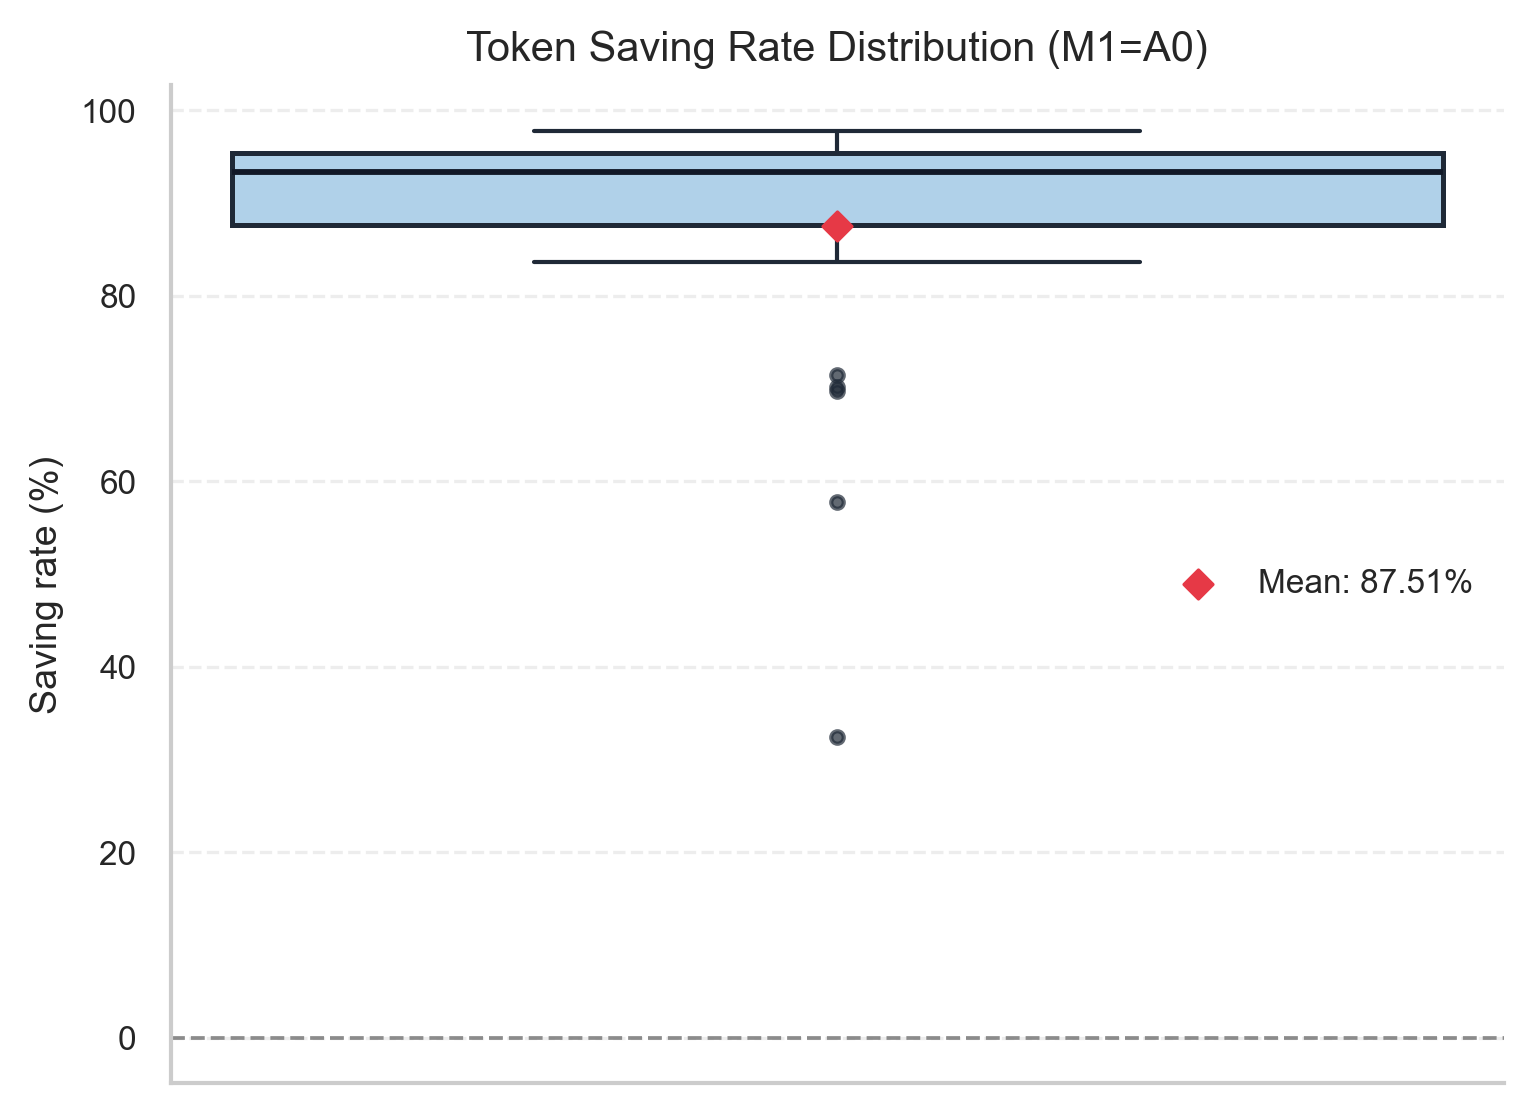

,Metric,Value
0,N reports,30.00
1,Mean saving rate (%),87.51
2,Median saving rate (%),93.31
3,Min saving rate (%),32.42
4,Max saving rate (%),97.76
5,Positive saving ratio (%),100.00


In [43]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------- checks ----------
required_cols = {"report_id", "M0", "M1", "save_rate", "save_rate_pct"}
if "result" not in globals():
    raise ValueError("`result` is not defined. Run the token comparison cell first.")
if not required_cols.issubset(result.columns):
    raise ValueError(f"`result` is missing columns: {required_cols - set(result.columns)}")
if result.empty:
    raise ValueError("`result` is empty; nothing to plot.")

if "target_m1_ablation" not in globals():
    target_m1_ablation = "A0"

# ---------- data ----------
plot_df = result[["save_rate_pct"]].copy()
plot_df["save_rate_pct"] = pd.to_numeric(plot_df["save_rate_pct"], errors="coerce")
plot_df = plot_df.dropna()

# ---------- style ----------
sns.set_theme(style="whitegrid", context="paper")
fig, ax = plt.subplots(figsize=(5.2, 3.8), dpi=300)

# Colored boxplot
sns.boxplot(
    y=plot_df["save_rate_pct"],
    width=0.36,
    color="#A7D3F2",  # light academic blue
    linewidth=1.2,
    fliersize=2.8,
    boxprops=dict(edgecolor="#1F2937"),
    whiskerprops=dict(color="#1F2937", linewidth=1.0),
    capprops=dict(color="#1F2937", linewidth=1.0),
    medianprops=dict(color="#111827", linewidth=1.4),
    flierprops=dict(
        marker='o',
        markerfacecolor="#1F2937",
        markeredgecolor="#1F2937",
        markersize=3,
        alpha=0.7
    ),
    ax=ax
)

# Mean marker
mean_v = plot_df["save_rate_pct"].mean()
ax.scatter(0, mean_v, marker="D", s=24, color="#E63946", zorder=4, label=f"Mean: {mean_v:.2f}%")

# Zero reference
ax.axhline(0, linestyle="--", linewidth=0.9, color="gray", alpha=0.9)

# Labels
ax.set_title(f"Token Saving Rate Distribution (M1={target_m1_ablation})", fontsize=10)
ax.set_ylabel("Saving rate (%)", fontsize=9)
ax.set_xlabel("")
ax.set_xticks([])

# Cosmetic tweaks
ax.tick_params(axis='y', labelsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.0)
ax.spines["bottom"].set_linewidth(1.0)
ax.grid(axis="y", linestyle="--", alpha=0.35)

ax.legend(frameon=False, fontsize=8, loc="best")
plt.tight_layout()
plt.show()

# ---------- keep summary table ----------
summary = pd.DataFrame({
    "Metric": [
        "N reports",
        "Mean saving rate (%)",
        "Median saving rate (%)",
        "Min saving rate (%)",
        "Max saving rate (%)",
        "Positive saving ratio (%)"
    ],
    "Value": [
        len(plot_df),
        plot_df["save_rate_pct"].mean(),
        plot_df["save_rate_pct"].median(),
        plot_df["save_rate_pct"].min(),
        plot_df["save_rate_pct"].max(),
        (plot_df["save_rate_pct"] > 0).mean() * 100
    ]
})

summary["Value"] = summary["Value"].apply(
    lambda v: round(v, 2) if isinstance(v, (int, float)) else v
)

display(summary)

In [45]:
import pandas as pd

pred = pd.read_csv('./predictions.csv')

for c in ['method', 'ablation', 'pred_disclosure_status', 'pred_evidence_text']:
    if c in pred.columns:
        pred[c] = pred[c].astype(str).str.strip()

pred['total_tokens'] = pd.to_numeric(pred.get('total_tokens'), errors='coerce').fillna(0)

a34 = pred[(pred['method'] == 'M1') & (pred['ablation'].isin(['A3', 'A4']))].copy()

summary = a34.groupby('ablation', dropna=False).agg(
    n_rows=('ablation', 'size'),
    total_tokens_sum=('total_tokens', 'sum'),
    avg_tokens=('total_tokens', 'mean'),
    not_disclosed_ratio=('pred_disclosure_status', lambda s: (s == 'not_disclosed').mean()),
    empty_evidence_ratio=('pred_evidence_text', lambda s: s.fillna('').astype(str).str.strip().eq('').mean()),
).reset_index()

display(summary)
print("All A3/A4 rows have total_tokens == 0:", a34['total_tokens'].eq(0).all())

,ablation,n_rows,total_tokens_sum,avg_tokens,not_disclosed_ratio,empty_evidence_ratio
0,A3,265,0.0,0.0,1.0,1.0
1,A4,265,0.0,0.0,1.0,1.0


All A3/A4 rows have total_tokens == 0: True


In [47]:
import pandas as pd
import numpy as np

labels = ['fully_disclosed', 'partially_disclosed', 'not_disclosed']
target_abls = ['A0', 'A1', 'A2', 'A5']

if 'eval_df' not in globals() or eval_df.empty:
    raise ValueError("eval_df is empty or not found. Please run GT matching first.")

tmp = eval_df.copy()
tmp['method'] = tmp['method'].astype(str).str.strip()
tmp['ablation'] = tmp['ablation'].astype(str).str.strip()
tmp['gt_disclosure_status'] = tmp['gt_disclosure_status'].astype(str).str.strip().str.lower()
tmp['pred_disclosure_status'] = tmp['pred_disclosure_status'].astype(str).str.strip().str.lower()

# Keep valid GT labels for status
tmp = tmp[tmp['gt_disclosure_status'].isin(labels)].copy()
# Invalid predicted label -> not_disclosed
tmp.loc[~tmp['pred_disclosure_status'].isin(labels), 'pred_disclosure_status'] = 'not_disclosed'

def norm_num_or_nan(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {'', 'n/a', 'na', 'none', 'null', '-', '--', '—'}:
        return np.nan
    s = s.replace(',', '')
    if s.endswith('%'):
        s = s[:-1].strip()
    try:
        v = float(s)
        return int(v) if abs(v - round(v)) < 1e-12 else v
    except Exception:
        return np.nan

def value_correct_including_na(gt, pred):
    g, p = norm_num_or_nan(gt), norm_num_or_nan(pred)
    if pd.isna(g) and pd.isna(p):
        return 1
    if pd.isna(g) ^ pd.isna(p):
        return 0
    return int(g == p)

def page_correct_including_na(gt, pred):
    g = pd.to_numeric(gt, errors='coerce')
    p = pd.to_numeric(pred, errors='coerce')
    if pd.isna(g) and pd.isna(p):
        return 1
    if pd.isna(g) ^ pd.isna(p):
        return 0
    return int(g == p)  # strict

# M1 + target ablations
m1 = tmp[(tmp['method'] == 'M1') & (tmp['ablation'].isin(target_abls))].copy()

rows = []
for abl in target_abls:
    d = m1[m1['ablation'] == abl].copy()
    if d.empty:
        rows.append({
            'Ablation': abl,
            'Acc_disclosure_status': np.nan,
            'Acc_value': np.nan,
            'Acc_page': np.nan
        })
        continue

    status_acc = (d['gt_disclosure_status'] == d['pred_disclosure_status']).mean()

    if {'gt_value', 'pred_value'}.issubset(d.columns):
        value_acc = d.apply(lambda r: value_correct_including_na(r['gt_value'], r['pred_value']), axis=1).mean()
    else:
        value_acc = np.nan

    if {'gt_page', 'pred_page'}.issubset(d.columns):
        page_acc = d.apply(lambda r: page_correct_including_na(r['gt_page'], r['pred_page']), axis=1).mean()
    else:
        page_acc = np.nan

    rows.append({
        'Ablation': abl,
        'Acc_disclosure_status': round(status_acc, 4),
        'Acc_value': round(value_acc, 4) if not pd.isna(value_acc) else np.nan,
        'Acc_page': round(page_acc, 4) if not pd.isna(page_acc) else np.nan
    })

acc_table = pd.DataFrame(rows).sort_values('Ablation').reset_index(drop=True)
display(acc_table)

# optional export
acc_table.to_csv('./analysis_outputs/m1_a0_a1_a2_a5_accuracy_only.csv', index=False, encoding='utf-8-sig')
print(acc_table.to_markdown(index=False))

,Ablation,Acc_disclosure_status,Acc_value,Acc_page
0,A0,0.9021,0.9319,0.8825
1,A1,0.9029,0.9397,0.8794
2,A2,0.9044,0.9397,0.8765
3,A5,0.9033,0.9417,0.8791


| Ablation   |   Acc_disclosure_status |   Acc_value |   Acc_page |
|:-----------|------------------------:|------------:|-----------:|
| A0         |                  0.9021 |      0.9319 |     0.8825 |
| A1         |                  0.9029 |      0.9397 |     0.8794 |
| A2         |                  0.9044 |      0.9397 |     0.8765 |
| A5         |                  0.9033 |      0.9417 |     0.8791 |


In [52]:
import pandas as pd
import numpy as np

# ---------- Load ----------
pred = pd.read_csv('./predictions.csv')
gt = pd.read_csv('./ground_truth.csv')
reports = pd.read_csv('./reports_metadata.csv')

# ---------- Basic clean ----------
for df in [pred, gt, reports]:
    for c in ['report_id', 'metric_id', 'method', 'ablation']:
        if c in df.columns:
            df[c] = df[c].astype(str).str.strip()

if 'model_name' in pred.columns:
    pred['model_name'] = pred['model_name'].astype(str).str.strip()
else:
    pred['model_name'] = ''

if 'model' in reports.columns:
    reports['model'] = reports['model'].astype(str).str.strip()
else:
    reports['model'] = ''

labels = ['fully_disclosed', 'partially_disclosed', 'not_disclosed']
pred['pred_disclosure_status'] = pred['pred_disclosure_status'].astype(str).str.strip().str.lower()
gt['gt_disclosure_status'] = gt['gt_disclosure_status'].astype(str).str.strip().str.lower()

# ---------- Model family ----------
def model_family(x):
    s = str(x).lower()
    if 'claude' in s or 'anthropic' in s:
        return 'claude'
    if 'gpt' in s or 'openai' in s:
        return 'gpt'
    return 'other'

pred['model_family'] = pred['model_name'].apply(model_family)
reports['model_family'] = reports['model'].apply(model_family)

# ---------- Keep latest prediction per (report_id, metric_id, method, ablation, model_name) ----------
if 'timestamp' in pred.columns:
    pred['timestamp'] = pd.to_datetime(pred['timestamp'], errors='coerce', utc=True)
    pred = pred.sort_values(['report_id', 'metric_id', 'method', 'ablation', 'model_name', 'timestamp'])
    pred_latest = pred.drop_duplicates(
        subset=['report_id', 'metric_id', 'method', 'ablation', 'model_name'],
        keep='last'
    ).copy()
else:
    pred_latest = pred.drop_duplicates(
        subset=['report_id', 'metric_id', 'method', 'ablation', 'model_name'],
        keep='last'
    ).copy()

# ---------- Rule: keep GPT only M1(A0), keep Claude all ----------
keep_mask = (
    (pred_latest['model_family'] == 'claude') |
    (
        (pred_latest['model_family'] == 'gpt') &
        (pred_latest['method'] == 'M1') &
        (pred_latest['ablation'].fillna('') == 'A0')
    )
)
pred_use = pred_latest[keep_mask].copy()

# ---------- Join with GT ----------
eval_df2 = pred_use.merge(
    gt[['report_id', 'metric_id', 'gt_disclosure_status', 'gt_value', 'gt_page']],
    on=['report_id', 'metric_id'],
    how='inner'
)

# valid GT only
eval_df2 = eval_df2[eval_df2['gt_disclosure_status'].isin(labels)].copy()
# invalid prediction label -> not_disclosed
eval_df2.loc[~eval_df2['pred_disclosure_status'].isin(labels), 'pred_disclosure_status'] = 'not_disclosed'

# ---------- Accuracy helpers ----------
def norm_num_or_nan(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {'', 'n/a', 'na', 'none', 'null', '-', '--', '—'}:
        return np.nan
    s = s.replace(',', '')
    if s.endswith('%'):
        s = s[:-1].strip()
    try:
        v = float(s)
        return int(v) if abs(v - round(v)) < 1e-12 else v
    except Exception:
        return np.nan

def value_correct_including_na(gtv, predv):
    g, p = norm_num_or_nan(gtv), norm_num_or_nan(predv)
    if pd.isna(g) and pd.isna(p):
        return 1
    if pd.isna(g) ^ pd.isna(p):
        return 0
    return int(g == p)

def page_correct_including_na(gtp, predp):
    g = pd.to_numeric(gtp, errors='coerce')
    p = pd.to_numeric(predp, errors='coerce')
    if pd.isna(g) and pd.isna(p):
        return 1
    if pd.isna(g) ^ pd.isna(p):
        return 0
    return int(g == p)  # strict

eval_df2['status_ok'] = (eval_df2['gt_disclosure_status'] == eval_df2['pred_disclosure_status']).astype(int)
eval_df2['value_ok'] = eval_df2.apply(
    lambda r: value_correct_including_na(r.get('gt_value', np.nan), r.get('pred_value', np.nan)),
    axis=1
)
eval_df2['page_ok'] = eval_df2.apply(
    lambda r: page_correct_including_na(r.get('gt_page', np.nan), r.get('pred_page', np.nan)),
    axis=1
)

acc_table = (
    eval_df2.groupby('model_family', dropna=False)
    .agg(
        Acc_disclosure_status=('status_ok', 'mean'),
        Acc_value=('value_ok', 'mean'),
        Acc_page=('page_ok', 'mean'),
    )
    .reset_index()
)

for c in ['Acc_disclosure_status', 'Acc_value', 'Acc_page']:
    acc_table[c] = acc_table[c].round(4)

# ---------- Token table with same filtering rule ----------
rep_keep = (
    (reports['model_family'] == 'claude') |
    (
        (reports['model_family'] == 'gpt') &
        (reports['method'] == 'M1') &
        (reports['ablation'].fillna('') == 'A0')
    )
)
tok = reports[rep_keep].copy()
tok['total_tokens'] = pd.to_numeric(tok['total_tokens'], errors='coerce')

tok_table = (
    tok.groupby('model_family', dropna=False)
    .agg(
        avg_total_tokens=('total_tokens', 'mean')
    )
    .reset_index()
)

tok_table['avg_total_tokens'] = tok_table['avg_total_tokens'].round(2)

# ---------- Final: keep only requested columns ----------
final_table = acc_table.merge(tok_table, on='model_family', how='outer')
final_table = final_table[
    ['model_family', 'Acc_disclosure_status', 'Acc_value', 'Acc_page', 'avg_total_tokens']
].sort_values('model_family').reset_index(drop=True)

display(final_table)

# optional export
final_table.to_csv(
    './analysis_outputs/claude_vs_gpt_m1a0_core_metrics.csv',
    index=False,
    encoding='utf-8-sig'
)
print("Saved: ./analysis_outputs/claude_vs_gpt_m1a0_core_metrics.csv")

,model_family,Acc_disclosure_status,Acc_value,Acc_page,avg_total_tokens
0,claude,0.9109,0.9352,0.8947,103074.68
1,gpt,0.9074,0.9338,0.8853,95736.87


Saved: ./analysis_outputs/claude_vs_gpt_m1a0_core_metrics.csv


## Robustness (Length / Industry)

In [49]:
import pandas as pd
import numpy as np

if 'eval_df' not in globals() or eval_df.empty:
    raise ValueError("eval_df is empty or not found. Please run GT matching first.")

reports = pd.read_csv('./reports_metadata.csv')
for c in ['report_id', 'method', 'ablation']:
    if c in reports.columns:
        reports[c] = reports[c].astype(str).str.strip()
reports['total_pages'] = pd.to_numeric(reports.get('total_pages'), errors='coerce')

labels = ['fully_disclosed', 'partially_disclosed', 'not_disclosed']

tmp = eval_df.copy()
for c in ['report_id', 'method', 'ablation', 'gt_disclosure_status', 'pred_disclosure_status']:
    if c in tmp.columns:
        tmp[c] = tmp[c].astype(str).str.strip()

tmp['gt_disclosure_status'] = tmp['gt_disclosure_status'].str.lower()
tmp['pred_disclosure_status'] = tmp['pred_disclosure_status'].str.lower()

tmp = tmp[tmp['gt_disclosure_status'].isin(labels)].copy()
tmp.loc[~tmp['pred_disclosure_status'].isin(labels), 'pred_disclosure_status'] = 'not_disclosed'

tmp = tmp[
    (tmp['method'].eq('M0')) |
    ((tmp['method'].eq('M1')) & (tmp['ablation'].fillna('').eq('A0')))
].copy()

meta = reports[
    (reports['method'].eq('M0')) |
    ((reports['method'].eq('M1')) & (reports['ablation'].fillna('').eq('A0')))
].copy()
meta = meta.sort_values(['report_id', 'method', 'ablation']).drop_duplicates(
    subset=['report_id', 'method', 'ablation'], keep='last'
)
meta = meta[['report_id', 'method', 'ablation', 'total_pages']]

tmp = tmp.merge(meta, on=['report_id', 'method', 'ablation'], how='left')

tmp['length_bin'] = pd.cut(
    tmp['total_pages'],
    bins=[-np.inf, 30, 80, np.inf],
    labels=['short(<=30)', 'medium(31-80)', 'long(>80)']
)

def norm_num_or_nan(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {'', 'n/a', 'na', 'none', 'null', '-', '--', '—'}:
        return np.nan
    s = s.replace(',', '')
    if s.endswith('%'):
        s = s[:-1].strip()
    try:
        v = float(s)
        return int(v) if abs(v - round(v)) < 1e-12 else v
    except Exception:
        return np.nan

def value_correct_including_na(gt, pred):
    g, p = norm_num_or_nan(gt), norm_num_or_nan(pred)
    if pd.isna(g) and pd.isna(p):
        return 1
    if pd.isna(g) ^ pd.isna(p):
        return 0
    return int(g == p)

def page_correct_including_na(gt, pred):
    g = pd.to_numeric(gt, errors='coerce')
    p = pd.to_numeric(pred, errors='coerce')
    if pd.isna(g) and pd.isna(p):
        return 1
    if pd.isna(g) ^ pd.isna(p):
        return 0
    return int(g == p)

tmp['status_ok'] = (tmp['gt_disclosure_status'] == tmp['pred_disclosure_status']).astype(int)
tmp['value_ok'] = tmp.apply(lambda r: value_correct_including_na(r['gt_value'], r['pred_value']), axis=1) if {'gt_value','pred_value'}.issubset(tmp.columns) else np.nan
tmp['page_ok'] = tmp.apply(lambda r: page_correct_including_na(r['gt_page'], r['pred_page']), axis=1) if {'gt_page','pred_page'}.issubset(tmp.columns) else np.nan

length_acc = (
    tmp.groupby(['length_bin', 'method', 'ablation'], dropna=False)
    .agg(
        n=('report_id', 'size'),
        acc_status=('status_ok', 'mean'),
        acc_value=('value_ok', 'mean'),
        acc_page=('page_ok', 'mean'),
    )
    .reset_index()
)

for c in ['acc_status', 'acc_value', 'acc_page']:
    length_acc[c] = (length_acc[c] * 100).round(2)

display(length_acc.sort_values(['length_bin', 'method', 'ablation']))

length_acc.to_csv('./analysis_outputs/robustness_length_accuracy.csv', index=False, encoding='utf-8-sig')
print("Saved: robustness_length_accuracy.csv")

,length_bin,method,ablation,n,acc_status,acc_value,acc_page
0,short(<=30),M0,NaN,123,96.75,98.37,86.99
1,short(<=30),M1,A0,246,95.93,97.56,94.72
2,medium(31-80),M0,NaN,371,83.02,87.87,71.70
3,medium(31-80),M1,A0,1081,86.68,90.19,84.37
4,long(>80),M0,NaN,201,91.04,97.51,82.09
5,long(>80),M1,A0,451,95.57,98.00,94.01


Saved: robustness_length_accuracy.csv
